# NB2: Core Annotation Study Results

**Narrative Framing**
* What question this notebook addresses: This notebook implements the specified sections to address the statistical analysis of the ground truth transition and performance impact.
* Which GT is being used as primary: Platinum GT
* Which KL1 strategy is active: Explicitly switchable (Default Strategy A - Exclusion)
* Central Narrative: Public medical imaging repository labels contain systematic, directionally biased noise that is invisible without platinum standard validation, and this noise quantifiably corrupts the performance metrics of annotation studies, AI benchmarks, and psychometric predictors derived from them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, f1_score, brier_score_loss
import pingouin as pg
import warnings
import helpers

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# 1. Load Data
KL1_STRATEGY = 'exclude' 
df = helpers.load_data(KL1_STRATEGY)
df_part = helpers.participant_summary(df)
df_img = helpers.image_summary(df)

df['human_correct_plat_int'] = df['human_correct_plat'].astype(int)

print("Setup Complete: Data loaded using 'exclude' strategy.")

mkdir -p failed for path /Users/martonbaltay/.matplotlib: [Errno 1] Operation not permitted: '/Users/martonbaltay/.matplotlib'


Matplotlib created a temporary cache directory at /var/folders/1g/t32yf_mn5pd5ymkl2yywtctr0000gn/T/matplotlib-2cke21y0 because there was an issue with the default path (/Users/martonbaltay/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


Setup Complete: Data loaded using 'exclude' strategy.


## Section 1 — Primary accuracy analysis

In [2]:
print("--- GEE Model: Accuracy ~ Condition ---")
model = smf.gee("human_correct_plat_int ~ C(condition, Treatment('no_ai'))", 
                groups=df["participant_id"], 
                data=df, family=sm.families.Binomial())
result = model.fit()
print(result.summary())

print("\nAccuracy by Condition:")
print(df.groupby('condition')['human_correct_plat'].mean())

--- GEE Model: Accuracy ~ Condition ---
                                GEE Regression Results                               
Dep. Variable:        human_correct_plat_int   No. Observations:                 3213
Model:                                   GEE   No. clusters:                       68
Method:                          Generalized   Min. cluster size:                  27
                        Estimating Equations   Max. cluster size:                  54
Family:                             Binomial   Mean cluster size:                47.2
Dependence structure:           Independence   Num. iterations:                     2
Date:                       Sat, 18 Apr 2026   Scale:                           1.000
Covariance type:                      robust   Time:                         15:09:53
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

## Section 2 — MRMC design analysis

In [3]:
print("--- GEE Model: Accuracy ~ Condition * Session ---")
model_mrmc = smf.gee("human_correct_plat_int ~ C(condition, Treatment('no_ai')) * C(session) + C(treatment_group)", 
                     groups=df["participant_id"], data=df, family=sm.families.Binomial())
result_mrmc = model_mrmc.fit()
print(result_mrmc.summary())

print("\nAccuracy by Condition and Session:")
print(df.groupby(['condition', 'session'])['human_correct_plat'].mean())

--- GEE Model: Accuracy ~ Condition * Session ---
                                GEE Regression Results                               
Dep. Variable:        human_correct_plat_int   No. Observations:                 3213
Model:                                   GEE   No. clusters:                       68
Method:                          Generalized   Min. cluster size:                  27
                        Estimating Equations   Max. cluster size:                  54
Family:                             Binomial   Mean cluster size:                47.2
Dependence structure:           Independence   Num. iterations:                     2
Date:                       Sat, 18 Apr 2026   Scale:                           1.000
Covariance type:                      robust   Time:                         15:09:53
                                                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

## Section 3 — Human-AI reliance analysis

In [4]:
print("Average Over-Reliance Rate:", df_part['over_reliance_rate'].mean())
print("Average Appropriate Skepticism Rate:", df_part['appropriate_skepticism_rate'].mean())

ai_cond = df[df['condition'] == 'ai']
rel_mat = pd.crosstab(
    ai_cond['ai_correct_plat'].replace({True: 'AI Correct', False: 'AI Incorrect'}),
    (ai_cond['final_decision'] == ai_cond['ai_prediction']).replace({True: 'Human Agreed', False: 'Human Disagreed'})
)
print("\nReliance Confusion Matrix:")
print(rel_mat)

Average Over-Reliance Rate: 0.07468123861566484
Average Appropriate Skepticism Rate: 0.14754098360655735

Reliance Confusion Matrix:
col_0            Human Agreed  Human Disagreed
ai_correct_plat                               
AI Correct               1089              192
AI Incorrect              123              243


## Section 4 — Confidence analysis

Overall Brier Score (Calibration Metric): 0.15928911247038496

Confidence change by AI Correctness:
ai_correct_plat
False   -0.057377
True     0.412959
Name: conf_change, dtype: float64


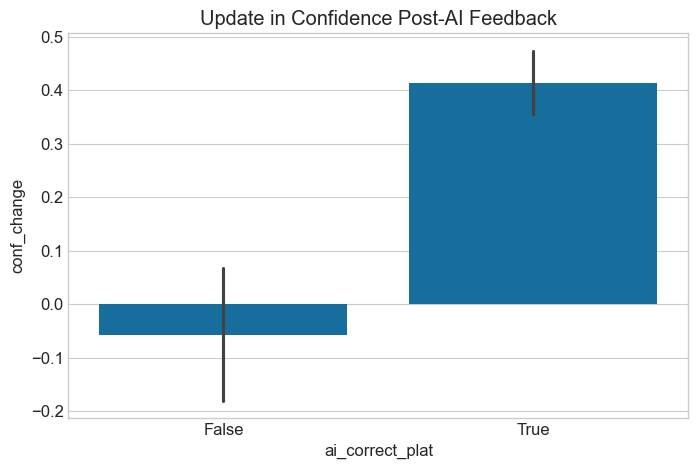

In [5]:
df['prob_1'] = df.apply(lambda x: x['final_confidence']/7.0 if x['final_decision'] == 1 else 1 - (x['final_confidence']/7.0), axis=1)
brier = brier_score_loss(df['gt_plat_binary'], df['prob_1'])
print("Overall Brier Score (Calibration Metric):", brier)

ai_cond = df[df['condition']=='ai'].copy()
ai_cond['conf_change'] = ai_cond['final_confidence'] - ai_cond['initial_confidence']
print("\nConfidence change by AI Correctness:")
print(ai_cond.groupby('ai_correct_plat')['conf_change'].mean())

plt.figure(figsize=(8,5))
sns.barplot(data=ai_cond, x='ai_correct_plat', y='conf_change')
plt.title("Update in Confidence Post-AI Feedback")
plt.show()

## Section 5 — Temporal dynamics

                                GEE Regression Results                               
Dep. Variable:        human_correct_plat_int   No. Observations:                 3213
Model:                                   GEE   No. clusters:                       68
Method:                          Generalized   Min. cluster size:                  27
                        Estimating Equations   Max. cluster size:                  54
Family:                             Binomial   Mean cluster size:                47.2
Dependence structure:           Independence   Num. iterations:                     2
Date:                       Sat, 18 Apr 2026   Scale:                           1.000
Covariance type:                      robust   Time:                         15:09:53
                                                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------

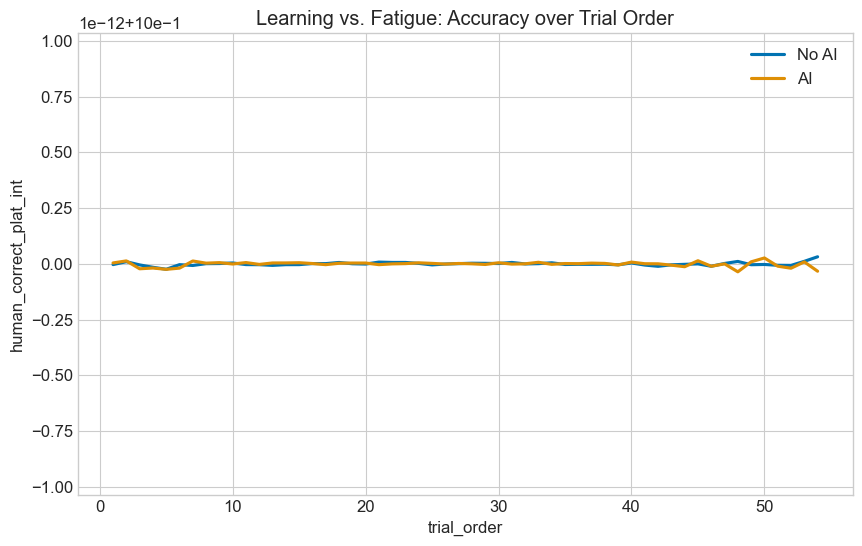

In [6]:
model_fatigue = smf.gee("human_correct_plat_int ~ trial_order * C(condition, Treatment('no_ai'))", 
                        groups=df["participant_id"], data=df, family=sm.families.Binomial())
print(model_fatigue.fit().summary())

plt.figure(figsize=(10,6))
sns.regplot(data=df[df['condition']=='no_ai'], x='trial_order', y='human_correct_plat_int', lowess=True, scatter=False, label='No AI')
sns.regplot(data=df[df['condition']=='ai'], x='trial_order', y='human_correct_plat_int', lowess=True, scatter=False, label='AI')
plt.title("Learning vs. Fatigue: Accuracy over Trial Order")
plt.legend()
plt.show()